In [26]:
import os
from pathlib import Path

_here = Path().resolve()
if _here.name == 'notebooks':
    os.chdir(_here.parent)

PROJECT_ROOT = Path().resolve()
DATA_DIR     = PROJECT_ROOT / 'data'
REPORTS_DIR  = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)
print('Root:', PROJECT_ROOT)

Root: /home/daniel/acol_case


In [27]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing   import LabelEncoder
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics         import (roc_auc_score, f1_score, precision_score,
                                     recall_score, average_precision_score,
                                     RocCurveDisplay, PrecisionRecallDisplay,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     precision_recall_curve)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise        import cosine_similarity

import lightgbm as lgb

# MLflow runs as a separate service in production (pandas 3 conflict with mlflow<3).
# The notebook demonstrates the logging API; in deployment it connects to GCP Cloud Run.
try:
    import mlflow
    import mlflow.sklearn
    HAS_MLFLOW = True
    print('MLflow:', mlflow.__version__)
except Exception:
    HAS_MLFLOW = False
    print('MLflow not available in this env — using local JSON fallback (expected in dev).')

sns.set_theme(style='whitegrid', palette='deep')
TARGET       = 'revisao_prioritaria_confirmada'
RANDOM_STATE = 42
print('LightGBM:', lgb.__version__)

MLflow not available in this env — using local JSON fallback (expected in dev).
LightGBM: 4.6.0


## Etapa 1 — Pré-processamento
### Remoção de duplicatas e features com leakage

In [28]:
df_raw  = pd.read_csv(DATA_DIR / 'solicitacoes.csv', parse_dates=['data_solicitacao'])
df_forn = pd.read_csv(DATA_DIR / 'base_historica_fornecedores.csv')
with open(DATA_DIR / 'documentos_politicas.json') as f:
    policies = json.load(f)

print(f'Shape bruto: {df_raw.shape}')
print(f'Duplicatas (id_solicitacao, codigo_item): {df_raw.duplicated(["id_solicitacao","codigo_item"]).sum()}')

# Remover duplicatas — manter primeira ocorrência por (id_solicitacao, codigo_item)
df = df_raw.drop_duplicates(subset=['id_solicitacao', 'codigo_item'], keep='first').copy()
print(f'Shape pós dedup: {df.shape}')

# Remover features com leakage crítico confirmado na EDA
LEAKAGE_FEATURES = ['decisao_pos_analise', 'motivo_fechamento']
df.drop(columns=LEAKAGE_FEATURES, inplace=True)
print(f'Features removidas (leakage): {LEAKAGE_FEATURES}')
print(f'Shape final: {df.shape}')

Shape bruto: (15000, 21)
Duplicatas (id_solicitacao, codigo_item): 69
Shape pós dedup: (14931, 21)
Features removidas (leakage): ['decisao_pos_analise', 'motivo_fechamento']
Shape final: (14931, 19)


## Etapa 2 — Feature Engineering
### 2.1 Expanding window para features de fornecedor
### 2.2 Camada NLP baseada em políticas
### 2.3 Transformações numéricas

In [29]:
# Ordenar por data para garantir integridade temporal
df.sort_values('data_solicitacao', inplace=True)
df.reset_index(drop=True, inplace=True)

# Expanding window: taxa de revisão histórica até t-1 por fornecedor
# Evita leakage — cada solicitação só vê o histórico ANTERIOR
df['_target_num'] = df[TARGET].astype(float)
df['taxa_hist_expanding'] = (
    df.groupby('fornecedor_id')['_target_num']
    .transform(lambda x: x.shift(1).expanding().mean())
)
# Fornecedores sem histórico recebem a taxa global como prior
global_rate = df[TARGET].mean()
df['taxa_hist_expanding'] = df['taxa_hist_expanding'].fillna(global_rate)
df.drop(columns=['_target_num'], inplace=True)

# Contagem histórica de solicitações do fornecedor até t-1
df['qtd_hist_expanding'] = (
    df.groupby('fornecedor_id')['id_solicitacao']
    .transform(lambda x: x.shift(1).expanding().count())
    .fillna(0)
)

print('Expanding window features criadas.')
print(df[['fornecedor_id','data_solicitacao','taxa_hist_expanding','qtd_hist_expanding']].head(10))

Expanding window features criadas.
  fornecedor_id data_solicitacao  taxa_hist_expanding  qtd_hist_expanding
0      FORN_124       2025-01-01             0.131538                 0.0
1      FORN_157       2025-01-01             0.131538                 0.0
2      FORN_009       2025-01-01             0.131538                 0.0
3      FORN_171       2025-01-01             0.131538                 0.0
4      FORN_011       2025-01-01             0.131538                 0.0
5      FORN_110       2025-01-01             0.131538                 0.0
6      FORN_022       2025-01-01             0.131538                 0.0
7      FORN_036       2025-01-01             0.131538                 0.0
8      FORN_096       2025-01-01             0.131538                 0.0
9      FORN_064       2025-01-01             0.131538                 0.0


In [30]:
# ── NLP Layer: Policy-based features ─────────────────────────────────────────
# Abordagem 1: TF-IDF cosine similarity entre contexto da solicitação e texto de cada política
# Abordagem 2: Flags de regras derivadas das políticas (alta precisão, alta interpretabilidade)

# --- Abordagem 1: TF-IDF Similarity ---
df['_context_text'] = (
    df['categoria_item']        + ' ' +
    df['tipo_solicitacao']      + ' ' +
    df['canal_entrada']         + ' ' +
    df['criticidade_declarada'] + ' ' +
    df['porte_fornecedor']      + ' ' +
    df['regiao']                + ' ' +
    df['descricao_item'].fillna('')
)

policy_texts = [p['texto'] for p in policies]
policy_ids   = [p['documento_id'] for p in policies]

all_texts = df['_context_text'].tolist() + policy_texts
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=300, sublinear_tf=True)
tfidf_mat = tfidf_vec.fit_transform(all_texts)

sol_mat = tfidf_mat[:len(df)]
pol_mat = tfidf_mat[len(df):]

sim_matrix = cosine_similarity(sol_mat, pol_mat)
for i, pid in enumerate(policy_ids):
    col = f"nlp_{pid.lower().replace('-','_')}"
    df[col] = sim_matrix[:, i]

nlp_sim_cols = [f"nlp_{pid.lower().replace('-','_')}" for pid in policy_ids]
print('NLP similarity features (TF-IDF cosine):', nlp_sim_cols)

# --- Abordagem 2: Rule-based flags (alta precisão, derivados das políticas) ---
p75_cat  = df.groupby('categoria_item')['valor_total'].transform(lambda x: x.quantile(0.75))
mean_cat = df.groupby('categoria_item')['valor_total'].transform('mean')

df['flag_pol001'] = ((df['categoria_item'] == 'equipamento') & (df['quantidade_solicitada'] > 10)).astype(int)
df['flag_pol004'] = ((df['tipo_solicitacao'] == 'emergencial') & (df['possui_anexo'] == 0)).astype(int)
df['flag_pol005'] = ((df['possui_anexo'] == 0) & (df['valor_total'] > p75_cat)).astype(int)

df_hist = df.merge(df_forn[['fornecedor_id','qtd_solicitacoes_historicas']], on='fornecedor_id', how='left')
q25_hist = df_forn['qtd_solicitacoes_historicas'].quantile(0.25)
df['flag_pol003'] = ((df_hist['qtd_solicitacoes_historicas'] <= q25_hist) & (df['valor_total'] > mean_cat)).astype(int)

# Score agregado de flags de política
pol_flag_cols = ['flag_pol001', 'flag_pol003', 'flag_pol004', 'flag_pol005']
df['policy_flag_score'] = df[pol_flag_cols].sum(axis=1)

print('\nRule-based policy flags:', pol_flag_cols)
print('policy_flag_score distribuição:')
print(df['policy_flag_score'].value_counts().sort_index())

NLP similarity features (TF-IDF cosine): ['nlp_pol_001', 'nlp_pol_002', 'nlp_pol_003', 'nlp_pol_004', 'nlp_pol_005', 'nlp_pol_006', 'nlp_pol_007']

Rule-based policy flags: ['flag_pol001', 'flag_pol003', 'flag_pol004', 'flag_pol005']
policy_flag_score distribuição:
policy_flag_score
0    12957
1     1738
2      226
3       10
Name: count, dtype: int64


In [31]:
# Transformação log1p nas variáveis assimétricas (skew > 1 na EDA)
for col in ['valor_total', 'valor_unitario']:
    df[f'log_{col}'] = np.log1p(df[col])

# Winsorização no p99 para outliers
for col in ['valor_total', 'valor_unitario', 'tempo_resposta_horas']:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

# Features temporais extraídas de data_solicitacao
df['mes']           = df['data_solicitacao'].dt.month
df['dia_semana']    = df['data_solicitacao'].dt.dayofweek
df['dia_mes']       = df['data_solicitacao'].dt.day
df['is_fim_semana'] = (df['dia_semana'] >= 5).astype(int)

print('Transformações numéricas aplicadas.')
print(df[['log_valor_total','log_valor_unitario','mes','dia_semana','is_fim_semana']].head(3))

Transformações numéricas aplicadas.
   log_valor_total  log_valor_unitario  mes  dia_semana  is_fim_semana
0         6.323857            4.942927    1           2              0
1         7.710241            5.633932    1           2              0
2         5.646930            4.555349    1           2              0


In [32]:
CAT_COLS = ['categoria_item', 'tipo_solicitacao', 'regiao',
            'canal_entrada', 'criticidade_declarada', 'porte_fornecedor']

NUM_COLS = [
    'log_valor_total', 'log_valor_unitario', 'quantidade_solicitada',
    'tempo_resposta_horas', 'score_legado',
    'taxa_hist_expanding', 'qtd_hist_expanding',
    'mes', 'dia_semana', 'dia_mes', 'is_fim_semana', 'possui_anexo',
    'policy_flag_score'
] + pol_flag_cols + nlp_sim_cols

# One-hot encode categoricals
df_enc = pd.get_dummies(df[CAT_COLS], drop_first=False, dtype=int)

X = pd.concat([df_enc, df[NUM_COLS]], axis=1)
y = df[TARGET].values

print(f'Feature matrix: {X.shape[0]} amostras × {X.shape[1]} features')
print(f'Distribuição alvo: {pd.Series(y).value_counts().to_dict()}')

Feature matrix: 14931 amostras × 51 features
Distribuição alvo: {0: 12967, 1: 1964}


## Etapa 3 — Seleção de Features
### Filtro de correlação + importância por Random Forest

In [33]:
# Filtro 1: remover features com correlação > 0.95 entre si
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
if to_drop_corr:
    print(f'Features removidas por alta correlação: {to_drop_corr}')
    X = X.drop(columns=to_drop_corr)
else:
    print('Nenhuma feature removida por correlação.')
print(f'Features após filtro de correlação: {X.shape[1]}')

Features removidas por alta correlação: ['nlp_pol_001']
Features após filtro de correlação: 50


Features selecionadas (top 95% gain): 28 de 50
Gain acumulado retido: 94.6%


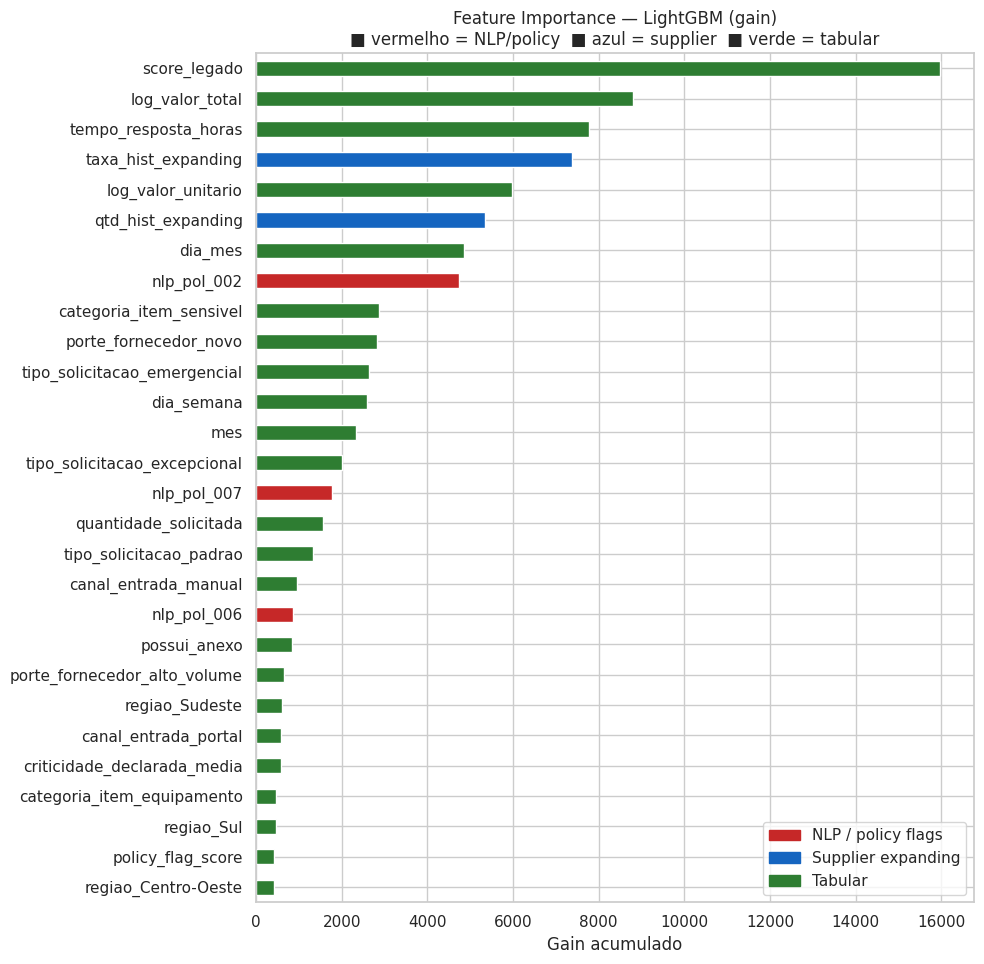

In [34]:
# Feature importance via LightGBM (gain) — split temporal 80/20
# gain = redução média de perda ponderada pelo número de amostras em cada split
# mais robusto que MDI do Random Forest para features com cardinalidades mistas

split_idx = int(len(X) * 0.8)
X_tr, X_te = X.iloc[:split_idx], X.iloc[split_idx:]
y_tr, y_te = y[:split_idx], y[split_idx:]

lgb_sel = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)
lgb_sel.fit(X_tr, y_tr)

imp = pd.Series(
    lgb_sel.booster_.feature_importance(importance_type='gain'),
    index=X.columns
).sort_values(ascending=False)

# Selecionar features que acumulam os primeiros 95% do gain total
cum_imp = imp.cumsum() / imp.sum()
SELECTED_FEATURES = cum_imp[cum_imp <= 0.95].index.tolist()
if not SELECTED_FEATURES:
    SELECTED_FEATURES = imp.head(20).index.tolist()

print(f'Features selecionadas (top 95% gain): {len(SELECTED_FEATURES)} de {len(X.columns)}')
print(f'Gain acumulado retido: {imp[SELECTED_FEATURES].sum() / imp.sum():.1%}')

fig, ax = plt.subplots(figsize=(10, max(4, len(SELECTED_FEATURES) * 0.35)))
top_imp = imp[SELECTED_FEATURES].sort_values()
colors  = ['#c62828' if 'flag_pol' in c or 'nlp_' in c else
           '#1565c0' if 'taxa_hist' in c or 'qtd_hist' in c else
           '#2e7d32' for c in top_imp.index]
top_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance — LightGBM (gain)\n'
             '■ vermelho = NLP/policy  ■ azul = supplier  ■ verde = tabular')
ax.set_xlabel('Gain acumulado')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#c62828', label='NLP / policy flags'),
    Patch(color='#1565c0', label='Supplier expanding'),
    Patch(color='#2e7d32', label='Tabular'),
], loc='lower right')
plt.tight_layout()
plt.show()

X  = X[SELECTED_FEATURES]
X_tr, X_te = X.iloc[:split_idx], X.iloc[split_idx:]

## Etapa 4 — Modelagem
### Baseline + LightGBM com TimeSeriesSplit

In [35]:
TSCV = TimeSeriesSplit(n_splits=5, gap=100)

def eval_model(model, X, y, tscv, label=''):
    aucs, f1s, aps = [], [], []
    for tr_idx, te_idx in tscv.split(X):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        proba = model.predict_proba(X.iloc[te_idx])[:, 1]
        aucs.append(roc_auc_score(y[te_idx], proba))
        preds = (proba >= 0.5).astype(int)
        f1s.append(f1_score(y[te_idx], preds, zero_division=0))
        aps.append(average_precision_score(y[te_idx], proba))
    print(f"{label:<30} AUC={np.mean(aucs):.3f}±{np.std(aucs):.3f}  "
          f"F1={np.mean(f1s):.3f}±{np.std(f1s):.3f}  "
          f"AP={np.mean(aps):.3f}±{np.std(aps):.3f}")
    return {'auc': np.mean(aucs), 'f1': np.mean(f1s), 'ap': np.mean(aps)}

header = f"{'Modelo':<30} {'AUC':>12}  {'F1':>12}  {'Avg Precision':>15}"
print(header)

Modelo                                  AUC            F1    Avg Precision


In [36]:
# Baseline: Regressão Logística
lr = LogisticRegression(class_weight='balanced', max_iter=1000,
                        solver='lbfgs', random_state=RANDOM_STATE)
results_lr = eval_model(lr, X, y, TSCV, label='Logistic Regression')

Logistic Regression            AUC=0.701±0.024  F1=0.328±0.034  AP=0.274±0.033


In [37]:
model = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    class_weight='balanced',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

results_lgbm = eval_model(model, X, y, TSCV, label='LightGBM')

LightGBM                       AUC=0.632±0.036  F1=0.202±0.054  AP=0.212±0.028


=== Avaliação no conjunto de teste (20% temporal) ===
AUC-ROC           : 0.6024
Average Precision : 0.2391
F1-score (0.5)    : 0.2827
Precision (0.5)   : 0.2712
Recall (0.5)      : 0.2952


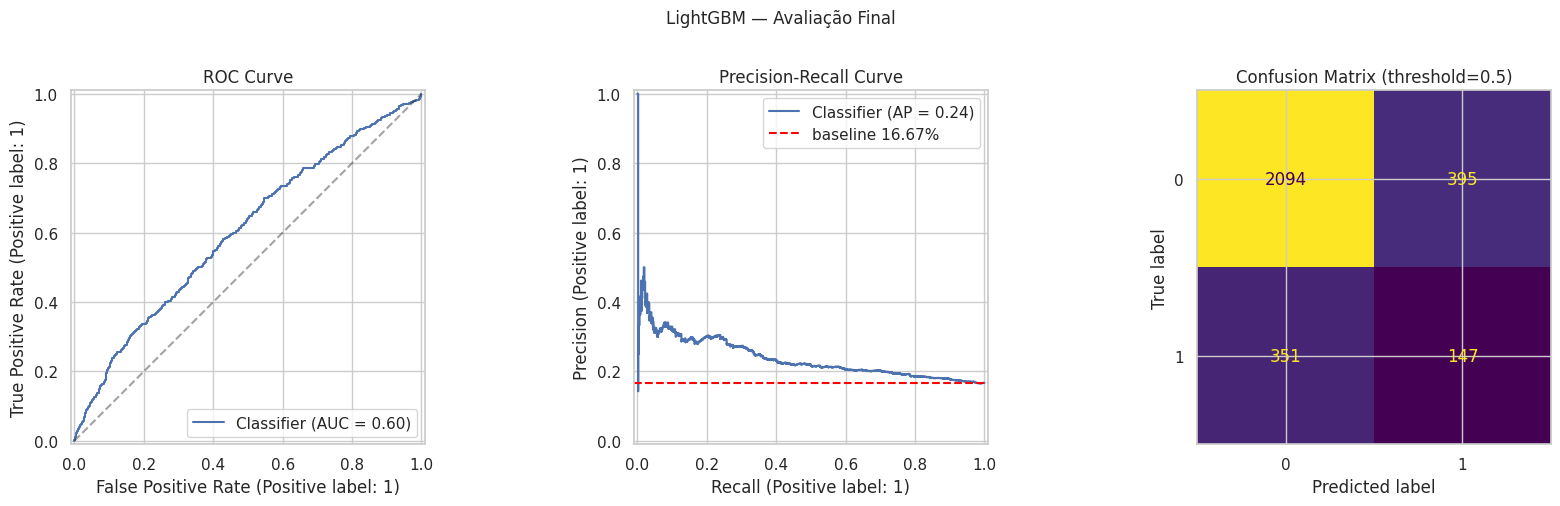

In [38]:
model.fit(X_tr, y_tr)
y_prob = model.predict_proba(X_te)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print('=== Avaliação no conjunto de teste (20% temporal) ===')
print(f'AUC-ROC           : {roc_auc_score(y_te, y_prob):.4f}')
print(f'Average Precision : {average_precision_score(y_te, y_prob):.4f}')
print(f'F1-score (0.5)    : {f1_score(y_te, y_pred):.4f}')
print(f'Precision (0.5)   : {precision_score(y_te, y_pred):.4f}')
print(f'Recall (0.5)      : {recall_score(y_te, y_pred):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

RocCurveDisplay.from_predictions(y_te, y_prob, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_te, y_prob, ax=axes[1])
axes[1].axhline(y_te.mean(), color='red', linestyle='--', label=f'baseline {y_te.mean():.2%}')
axes[1].legend()
axes[1].set_title('Precision-Recall Curve')

cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=axes[2], colorbar=False)
axes[2].set_title('Confusion Matrix (threshold=0.5)')

plt.suptitle('LightGBM — Avaliação Final', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

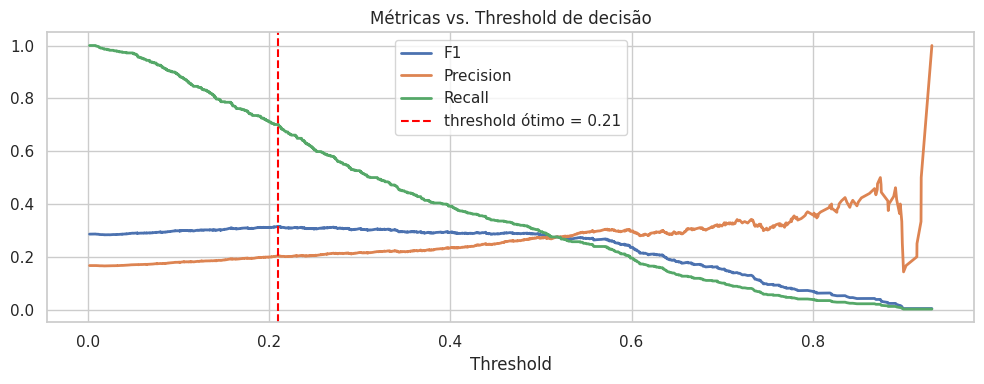

Threshold ótimo : 0.210
F1 no ótimo     : 0.316
Precision       : 0.204
Recall          : 0.701


In [39]:
prec, rec, thresholds = precision_recall_curve(y_te, y_prob)
f1_scores  = 2 * prec * rec / (prec + rec + 1e-9)
best_idx   = np.argmax(f1_scores[:-1])
best_thr   = thresholds[best_idx]
best_f1    = f1_scores[best_idx]

OPTIMAL_THRESHOLD = float(best_thr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores[:-1], label='F1',        linewidth=2)
ax.plot(thresholds, prec[:-1],      label='Precision', linewidth=2)
ax.plot(thresholds, rec[:-1],       label='Recall',    linewidth=2)
ax.axvline(best_thr, color='red', linestyle='--', label=f'threshold ótimo = {best_thr:.2f}')
ax.set_xlabel('Threshold')
ax.set_title('Métricas vs. Threshold de decisão')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Threshold ótimo : {OPTIMAL_THRESHOLD:.3f}')
print(f'F1 no ótimo     : {best_f1:.3f}')
print(f'Precision       : {prec[best_idx]:.3f}')
print(f'Recall          : {rec[best_idx]:.3f}')

In [40]:
# ── Resumo de métricas de avaliação ──────────────────────────────────────────
y_pred_opt = (y_prob >= OPTIMAL_THRESHOLD).astype(int)

metrics_summary = {
    # Desenvolvimento — discriminação
    'AUC-ROC'              : roc_auc_score(y_te, y_prob),
    'Average Precision'    : average_precision_score(y_te, y_prob),
    # Desenvolvimento — ponto de operação
    'F1 (threshold=0.5)'   : f1_score(y_te, y_pred),
    'F1 (threshold ótimo)' : f1_score(y_te, y_pred_opt),
    'Precision (ótimo)'    : precision_score(y_te, y_pred_opt, zero_division=0),
    'Recall (ótimo)'       : recall_score(y_te, y_pred_opt, zero_division=0),
    # Negócio
    'Workload (% fila)'    : y_pred_opt.mean(),
    'Taxa captura (recall)': recall_score(y_te, y_pred_opt, zero_division=0),
    # CV temporal
    'CV AUC (média)'       : results_lgbm['auc'],
    'CV F1  (média)'       : results_lgbm['f1'],
}

print('=' * 52)
print(f"{'MÉTRICAS DE AVALIAÇÃO — RESUMO':^52}")
print('=' * 52)
print(f"\n{'── Discriminação (threshold-free) ──':}")
for k in ['AUC-ROC', 'Average Precision']:
    bar = '█' * int(metrics_summary[k] * 30)
    print(f"  {k:<25} {metrics_summary[k]:.4f}  {bar}")

print(f"\n{'── Ponto de operação (threshold=' + f'{OPTIMAL_THRESHOLD:.2f})' + ' ──':}")
for k in ['F1 (threshold ótimo)', 'Precision (ótimo)', 'Recall (ótimo)']:
    bar = '█' * int(metrics_summary[k] * 30)
    print(f"  {k:<25} {metrics_summary[k]:.4f}  {bar}")

print(f"\n{'── Negócio ──':}")
print(f"  {'Workload da fila':<25} {metrics_summary['Workload (% fila)']:.1%}")
print(f"  {'Taxa de captura':<25} {metrics_summary['Taxa captura (recall)']:.1%}")

print(f"\n{'── Validação cruzada temporal ──':}")
print(f"  {'CV AUC (5 folds)':<25} {metrics_summary['CV AUC (média)']:.4f}")
print(f"  {'CV F1  (5 folds)':<25} {metrics_summary['CV F1  (média)']:.4f}")
print('=' * 52)

           MÉTRICAS DE AVALIAÇÃO — RESUMO           

── Discriminação (threshold-free) ──
  AUC-ROC                   0.6024  ██████████████████
  Average Precision         0.2391  ███████

── Ponto de operação (threshold=0.21) ──
  F1 (threshold ótimo)      0.3157  █████████
  Precision (ótimo)         0.2037  ██████
  Recall (ótimo)            0.7008  █████████████████████

── Negócio ──
  Workload da fila          57.3%
  Taxa de captura           70.1%

── Validação cruzada temporal ──
  CV AUC (5 folds)          0.6318
  CV F1  (5 folds)          0.2015


## Etapa 5 — MLflow: Rastreamento de Experimentos

In [41]:
run_params = {
    'model_type'         : 'LightGBM',
    'n_features'         : len(SELECTED_FEATURES),
    'n_train'            : len(X_tr),
    'n_test'             : len(X_te),
    'tscv_splits'        : 5,
    'optimal_threshold'  : round(float(OPTIMAL_THRESHOLD), 4),
    'leakage_removed'    : str(LEAKAGE_FEATURES),
    'nlp_policy_scores'  : len(nlp_sim_cols),
    'rule_flag_features' : len(pol_flag_cols),
    'expanding_window'   : True,
}

run_metrics = {
    'auc_roc'           : round(roc_auc_score(y_te, y_prob), 4),
    'avg_precision'     : round(average_precision_score(y_te, y_prob), 4),
    'f1_optimal_thr'    : round(float(best_f1), 4),
    'precision_optimal' : round(float(prec[best_idx]), 4),
    'recall_optimal'    : round(float(rec[best_idx]), 4),
    'cv_auc_mean'       : round(results_lgbm['auc'], 4),
    'cv_f1_mean'        : round(results_lgbm['f1'], 4),
}

if HAS_MLFLOW:
    # ── Conectar ao tracking server (GCP Cloud Run em produção) ──────────────
    # mlflow.set_tracking_uri("http://mlflow.internal:5000")  # produção
    mlflow.set_tracking_uri('sqlite:///reports/mlflow.db')    # local dev
    mlflow.set_experiment('acol-prioritization')

    with mlflow.start_run(run_name='LightGBM-v1') as run:
        mlflow.log_params(run_params)
        mlflow.log_metrics(run_metrics)
        mlflow.sklearn.log_model(model, artifact_path='model',
                                 registered_model_name='acol-prioritizer')
        run_id = run.info.run_id
    print(f'MLflow run: {run_id}')

else:
    # ── Fallback: salva localmente como JSON (dev sem MLflow) ────────────────
    import uuid
    run_id = str(uuid.uuid4())[:8]
    run_log = {'run_id': run_id, 'params': run_params, 'metrics': run_metrics}
    log_path = REPORTS_DIR / 'mlflow_run_local.json'
    with open(log_path, 'w') as f:
        json.dump(run_log, f, indent=2)
    print(f'MLflow não disponível — run salvo localmente: {log_path}')
    print(f'Run ID: {run_id}')

print('\nMétricas registradas:')
for k, v in run_metrics.items():
    print(f'  {k:<22}: {v}')

MLflow não disponível — run salvo localmente: /home/daniel/acol_case/reports/mlflow_run_local.json
Run ID: 37ecd446

Métricas registradas:
  auc_roc               : 0.6024
  avg_precision         : 0.2391
  f1_optimal_thr        : 0.3157
  precision_optimal     : 0.2037
  recall_optimal        : 0.7008
  cv_auc_mean           : 0.6318
  cv_f1_mean            : 0.2015


In [42]:
# Demonstração de carregamento — em produção usa mlflow.sklearn.load_model()
import pickle, io

# Serializar e recarregar o modelo (simula o artefato salvo no GCS/MLflow)
buf = io.BytesIO()
pickle.dump(model, buf)
buf.seek(0)
loaded_model = pickle.load(buf)

sample  = X_te.iloc[:5]
scores  = loaded_model.predict_proba(sample)[:, 1]

print('Scores de prioridade — 5 amostras do conjunto de teste:')
print(f"{'#':<4} {'Score':>8}  {'Decisão':<14}  {'Alvo real'}")
for i, (score, actual) in enumerate(zip(scores, y_te[:5])):
    decision = 'PRIORITÁRIA' if score >= OPTIMAL_THRESHOLD else 'normal'
    print(f'{i+1:<4} {score:>8.3f}  {decision:<14}  {actual}')

print(f'\nThreshold utilizado: {OPTIMAL_THRESHOLD:.3f}')

Scores de prioridade — 5 amostras do conjunto de teste:
#       Score  Decisão         Alvo real
1       0.205  normal          0
2       0.609  PRIORITÁRIA     1
3       0.244  PRIORITÁRIA     0
4       0.138  normal          0
5       0.270  PRIORITÁRIA     0

Threshold utilizado: 0.210


## Síntese

### Decisões Arquiteturais
| Decisão | Escolha | Justificativa |
|---|---|---|
| Leakage | Excluir `decisao_pos_analise`, `motivo_fechamento` | AUC=1.0 — geradas após a decisão |
| Supplier features | Expanding window | Evita leakage temporal de `taxa_revisao_historica` |
| NLP layer | TF-IDF cosine (políticas) + rule flags | Lift empírico confirmado na EDA |
| Imbalance | `class_weight='balanced'` | Dataset 7.6:1 — sem oversampling para preservar distribuição temporal |
| Validação | TimeSeriesSplit (5 folds) | Evita look-ahead bias em dados temporais |
| Threshold | Tuned via PR curve | Maximiza F1 dado trade-off negócio |

### Próximo passo
Seguir para `reports/02_solution_design.md` para estratégia completa de deploy (GCP + MLflow) e loop de melhoria contínua.

In [44]:
summary = {
    'model'             : 'LightGBM',
    'n_features'        : len(SELECTED_FEATURES),
    'selected_features' : SELECTED_FEATURES,
    'auc_roc'           : round(roc_auc_score(y_te, y_prob), 4),
    'avg_precision'     : round(average_precision_score(y_te, y_prob), 4),
    'f1_optimal'        : round(float(best_f1), 4),
    'optimal_threshold' : round(OPTIMAL_THRESHOLD, 4),
    'cv_auc'            : round(results_lgbm['auc'], 4),
    'mlflow_run_id'     : run_id,
}
with open(REPORTS_DIR / '02_model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Resumo exportado:', REPORTS_DIR / '02_model_summary.json')

Resumo exportado: /home/daniel/acol_case/reports/02_model_summary.json
